<a href="https://colab.research.google.com/github/bensonmacharia/ML/blob/main/martingale_coinflips.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Martingale on Coin Flip Games with Python

The Martingale strategy is a betting system where a player doubles their bet after every loss so that when they eventually win, they recover all previous losses and make a profit equal to the original bet. For example, if the starting bet is 100 and the player loses, the next bet becomes 200, then 400, then 800, and so on until a win occurs. After a win, the bet resets back to the original amount. The strategy assumes that a win will eventually happen, but it can become very risky because the required bets grow very quickly and may exceed the player’s available bank balance or betting limits.

## Simulation Framework



### A single coin flip

The outcome of a coin flip is simulated and defined as a by randomly drawing either a 1 or a 0 with the `random` class and encoding these integers as heads and tails, respectively.

In [ ]:
# heads == 1
# tails == 0

import random

def coinflip(): return random.randint(0,1)

sidecoin = coinflip()
print("{}: {}".format(sidecoin, "heads" if sidecoin else "tails" ))


1: heads


### Betting decisions with and without the Martingale strategy

The Martingale strategy is used to increase chances of financial recovery from losing streaks in betting games by doubling up on losing bets. This suggests the Martingale system makes decisions for the future based on the current outcome.

A `martingale()` function has been written below. This function returns the amount of money left after the current bet (`bank`), the current `guess`, and the next `bet` to be made. The next `bet` is doubled if the drawn coin does not match the current guess (loss), or returned back to the initial `base_bet` once the drawn coin matches the bet (win).

As a control, the non-strategy was also written as the `no_strat()` function. For this scenario, the `bet` amount is kept unchanged regardless of outcome.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def martingale(bank, guess, base_bet, bet):
    'betting outcome and next decision using the martingale. A base bet is the conventional (init) bet '

    coinflip_out = coinflip()

    if guess != coinflip_out:
        # print('you lost! double your bet!')
        bank -= bet
        bet *= 2
    else:
        # print('you won!')
        guess = random.randint(0,1)
        bank += bet
        bet = base_bet

    return bank, guess, bet

def no_strat(bank, guess, base_bet, bet):
    'betting outcome and next decision (no effect on outcome) '

    coinflip_out = coinflip()

    if guess != coinflip_out:
        # print('you lost!')
        guess = random.randint(0,1)
        bank -= bet
        # bet *= 2
    else:
        # print('you won!')
        guess = random.randint(0,1)
        bank += bet
        # bet = base_bet

    return bank, guess, bet



The above are expanded from a single coin flip to the outcomes of a more extensive coin-flipping game with multiple $N$ coin flips. In addition, this is a game played by a single player starting with a bank account balance of \$1,000 and a base bet of $100:

In [ ]:
def singleplayer(func, N=10000, bank=1000, base_bet=100):

    guess = random.randint(0,1)
    bet = base_bet

    bethistory = []
    ix = []

    for i in range(N):
        bank, guess, bet = func(bank, guess, base_bet, bet)
        bethistory.append(bank)
        ix.append(i)

    # Assign colors automatically
    colors = {
        'no_strat': 'red',
        'martingale': 'blue'
    }

    # plt.plot(
    #     ix,
    #     bethistory,
    #     color=colors.get(func.__name__, 'black'),
    #     label=func.__name__
    # )

    # plt.xlabel('number of bets')
    # plt.ylabel('bank')
    # plt.title('Bank Balance Comparison')
    # plt.legend()

    return bethistory


# singleplayer(no_strat)
# singleplayer(martingale)

# plt.show()


The above can then be further expanded to a full coin-flipping game with multiple $N$ coin flips and multiple players defined by the $players$ variable. All players also start with a bank account balance of \$1,000 and make base bets of $100.

In [ ]:
def game(players,func):

    print(func.__name__)
    # plt.figure()
    banks = []
    for j in range(players):
        bethist = singleplayer(func, N=10000,bank=1000,base_bet=100)
        # banks.append(bank)
        banks.append(bethist)
    banks = np.array(banks)

    # print('all banks (100)', banks)
    print('\naverage ending bank balance: ${}'.format(np.mean(banks[:,-1])))
    print('\nending bank balance std. deviation: ${}'.format(np.std(banks[:,-1])))

    return banks



## Results

The above `game(players,func)` function can be applied to games where players either apply the martingale strategy or not with the `func` input variable. Below we run the statistics for coinflip games played by 100 players with and without the strategy, where each game is played for 10,000 coin flips.

In [ ]:
N = 100 # number of players
bns = game(N,no_strat)
print('\n\n')
bm = game(N,martingale)


no_strat

average ending bank balance: $1462.0

ending bank balance std. deviation: $9000.78641008662



martingale

average ending bank balance: $500207.0

ending bank balance std. deviation: $4477.281652967568


In [ ]:
def plots(data,func):

  plt.figure()
  [plt.plot(i,alpha=0.25,zorder=1) for i in data]
  plt.hlines(0,0,10000,color='darkred',linestyles='dashed')
  plt.ylabel("Betting money / USD ($)")
  plt.xlabel("coin flip epoch")
  plt.title(func.__name__)

from scipy import stats as st

def histograms(data,func):
  # plt.figure()
  y, x, _ = plt.hist(data[:,-1],alpha=0.5,label=func.__name__)

  if x.min() < 0:
    plt.vlines(0,0,y.max(),color='darkred',linestyles='dashed')
    print(x.min())


The outcomes of multiple-player games are shown below in a more graphical sense, where the amount of money each player holds is tracked over the 10,000 coin flips.

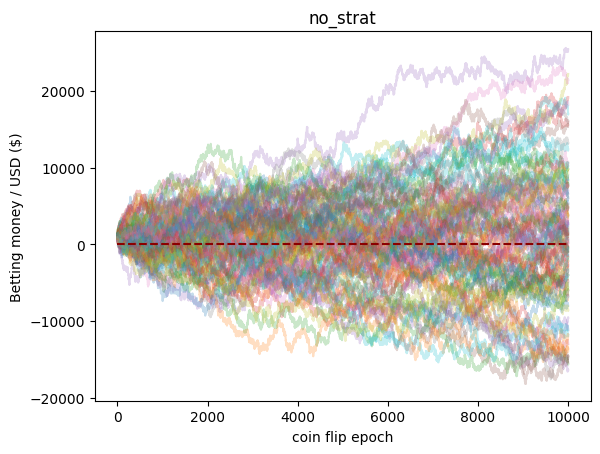

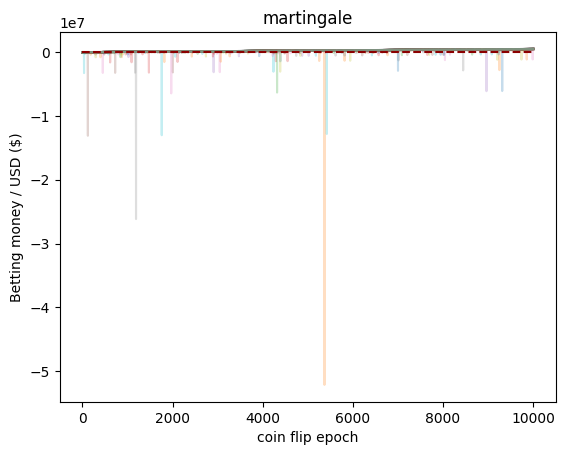

In [ ]:
plots(bns,no_strat)
plots(bm,martingale)

Evidently, it can be seen by the division of the dashed red line that there are as many players winning as there are losing when no strategy is  implemented.

What may be of higher importance is the final amount of money gained (or lost) by the players after the game is over. This is represented below at the population level with histograms, where a dashed red line is drawn at the limit of $0.

-16400.0


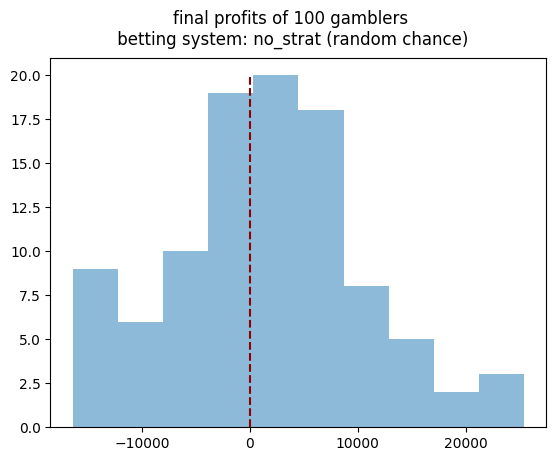

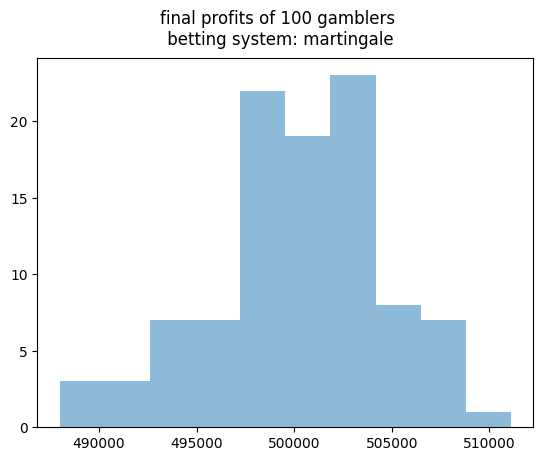

In [ ]:
# with plt.style.context('dark_background'):

plt.figure()
plt.suptitle('final profits of 100 gamblers\n betting system: no_strat (random chance)')
histograms(bns,no_strat)

plt.figure()
plt.suptitle('final profits of 100 gamblers\n betting system: martingale')
histograms(bm,martingale)

Though a substantial amount of players lose when no strategy is implemented, when Martingale is applied under these selected conditions not only is there no profit loss for all players, but most make a profit of about $1 million.

The final plot below shows the stark difference in the final profits of 100 players applying and not applying the martingale strategy for the selected game simulation conditions.

-16400.0


Text(0.5, 0.98, 'final profits of 100 players\n comparison')

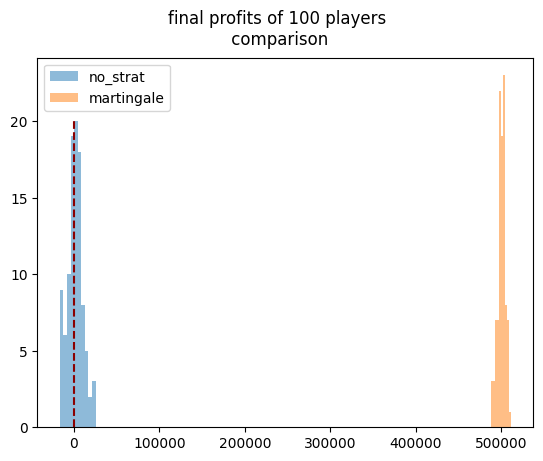

In [ ]:
# with plt.style.context('dark_background'):
plt.figure()

histograms(bns,no_strat)
histograms(bm,martingale)
plt.legend()
plt.suptitle('final profits of 100 players\n comparison')

Although having a strategy may always help, this is by no means an endorsement of the Martingale strategy. The simulations here show a controlled environment; under the specified game constraints this may be favorable strategy, but that may not be the case in others.